In [1]:
from pathlib import Path
import re
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image

In [ ]:
CAPTURES_DIR = Path("build/debug/captures")

frames = sorted(
    {int(m.group(1)) for p in CAPTURES_DIR.glob("frame_*.bmp")
     if (m := re.search(r'frame_(\d+)', p.name))},
    reverse=True
)
print(f"{len(frames)} capture(s): {[f'frame_{i:04d}' for i in frames]}")

def load_frame(idx):
    stem = CAPTURES_DIR / f"frame_{idx:04d}"
    return (
        np.array(Image.open(f"{stem}_prev_ssaa.bmp").convert("RGB")),
        np.array(Image.open(f"{stem}_ssaa.bmp").convert("RGB")),
        np.array(Image.open(f"{stem}_aliased.bmp").convert("RGB")),
        np.load(f"{stem}_depth.npy"),
        np.load(f"{stem}_motion.npy").astype(np.float32),  # (H, W, 2) float16 -> float32
        np.load(f"{stem}_jitter.npy"),                     # (2, 2): [[curr_x,y], [prev_x,y]] pixels
    )

def show_frame(idx, mv_step=20, mv_min_mag=1e-4):
    prev_ssaa, ssaa, aliased, depth, motion, jitter = load_frame(idx)
    mask  = depth < 1.0
    vals  = depth[mask]
    d_vis = np.where(mask, depth, np.nan)
    mag   = np.sqrt(motion[..., 0] ** 2 + motion[..., 1] ** 2)

    fig = plt.figure(figsize=(30, 16), constrained_layout=True)
    fig.suptitle(f"frame_{idx:04d}  —  800×450  |  jitter curr=({jitter[0,0]:.3f}, {jitter[0,1]:.3f}) px  prev=({jitter[1,0]:.3f}, {jitter[1,1]:.3f}) px", fontsize=13)
    gs = gridspec.GridSpec(2, 3, figure=fig)

    for ax, img, title in zip(
        [fig.add_subplot(gs[0, i]) for i in range(3)],
        [prev_ssaa, ssaa, aliased],
        ["Prev SSAA", "SSAA", "Aliased"],
    ):
        ax.imshow(img, aspect="auto")
        ax.set_title(title, fontsize=12)
        ax.axis("off")

    ax = fig.add_subplot(gs[1, 0])
    im = ax.imshow(d_vis, cmap="viridis_r", vmin=vals.min(), vmax=vals.max(), aspect="auto")
    ax.set_title("Depth (D32_FLOAT)", fontsize=12); ax.axis("off")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02)

    ax = fig.add_subplot(gs[1, 1])
    im = ax.imshow(mag, cmap="hot", aspect="auto")
    ax.set_title("MV magnitude (NDC)", fontsize=12); ax.axis("off")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02)

    H, W = motion.shape[:2]
    ys = np.arange(mv_step // 2, H, mv_step)
    xs = np.arange(mv_step // 2, W, mv_step)
    xg, yg = np.meshgrid(xs, ys)
    dx, dy  = motion[yg, xg, 0], motion[yg, xg, 1]
    qmag    = np.sqrt(dx**2 + dy**2)
    qmask   = qmag > mv_min_mag

    ax = fig.add_subplot(gs[1, 2])
    ax.set_facecolor("#111")
    ax.set_xlim(0, W); ax.set_ylim(H, 0)
    ax.set_title("Motion vectors", fontsize=12)
    ax.axis("off")
    if qmask.any():
        q = ax.quiver(xg[qmask], yg[qmask], dx[qmask], -dy[qmask], qmag[qmask],
                      cmap="plasma", scale=None, scale_units="xy",
                      angles="xy", width=0.003)
        fig.colorbar(q, ax=ax, fraction=0.046, pad=0.02, label="NDC mag")

    plt.show()
    print(f"  object pixels : {mask.sum():,}/{depth.size:,} ({100*mask.mean():.1f}%)")
    print(f"  MV range      : [{motion.min():.4f}, {motion.max():.4f}]  mag max={mag.max():.4f}")
    print(f"  jitter curr   : ({jitter[0,0]:.4f}, {jitter[0,1]:.4f}) px")
    print(f"  jitter prev   : ({jitter[1,0]:.4f}, {jitter[1,1]:.4f}) px")

C:\Users\magno\AppData\Local\Temp\ipykernel_21340\843735126.py:43: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


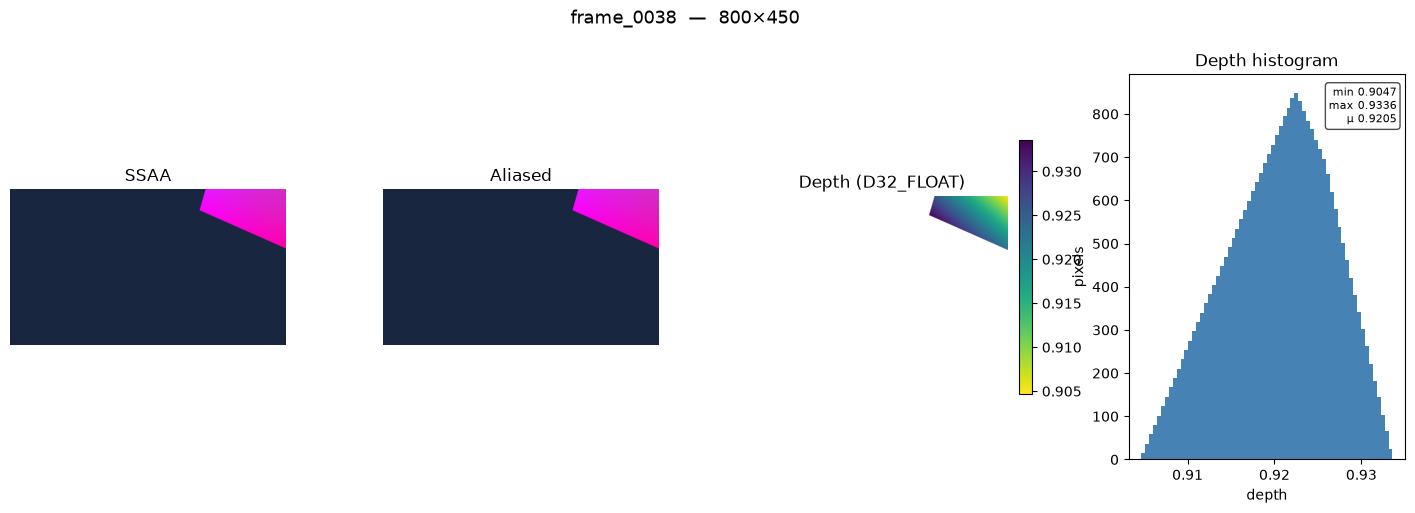

  object pixels: 28,632/360,000 (8.0%)


In [3]:
# show the most recent capture
if frames:
    show_frame(frames[0])
else:
    print("No captures found. Press C in the app to capture a frame.")

In [ ]:
def show_motion_vectors(idx, step=20, min_mag=1e-4):
    """Quiver plot of motion vectors, subsampled every `step` pixels.
    Arrows excluded where magnitude < min_mag (background / static pixels)."""
    _, _, _, _, motion = load_frame(idx)
    H, W = motion.shape[:2]

    ys = np.arange(step // 2, H, step)
    xs = np.arange(step // 2, W, step)
    xg, yg = np.meshgrid(xs, ys)

    dx = motion[yg, xg, 0]   # NDC x displacement
    dy = motion[yg, xg, 1]   # NDC y displacement (positive = up in NDC)
    mag = np.sqrt(dx**2 + dy**2)

    mask = mag > min_mag
    xp, yp = xg[mask], yg[mask]
    u, v   = dx[mask], -dy[mask]  # flip Y: NDC up = screen down
    c      = mag[mask]

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.set_xlim(0, W); ax.set_ylim(H, 0)
    ax.set_facecolor("#111")
    ax.set_title(f"frame_{idx:04d} — motion vectors (step={step}px, {mask.sum()} arrows)")
    ax.set_aspect("equal")

    q = ax.quiver(xp, yp, u, v, c,
                  cmap="plasma", scale=None, scale_units="xy",
                  angles="xy", width=0.003)
    plt.colorbar(q, ax=ax, label="NDC magnitude")
    plt.tight_layout()
    plt.show()
    print(f"  non-zero arrows: {mask.sum()}  |  mag mean={c.mean():.5f}  max={c.max():.5f}")

if frames:
    show_motion_vectors(frames[0])

C:\Users\magno\AppData\Local\Temp\ipykernel_21340\843735126.py:43: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


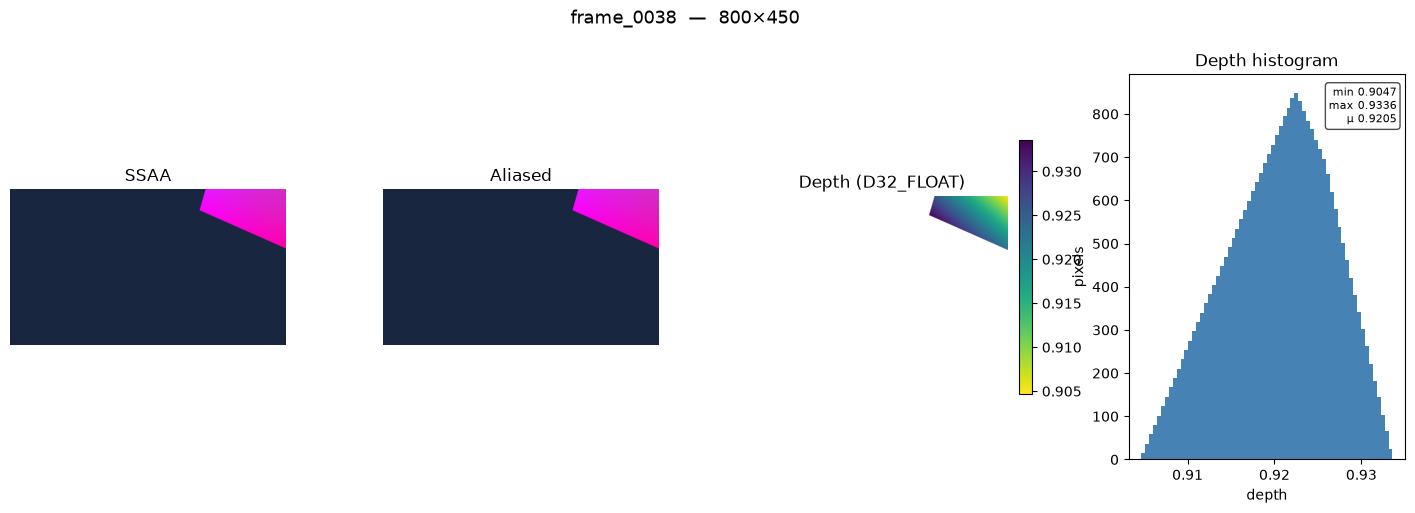

  object pixels: 28,632/360,000 (8.0%)


In [4]:
if frames:
    show_frame(frames[0])
else:
    print("No captures found. Press C in the app to capture a frame.")